<a href="https://colab.research.google.com/github/seekff/learn-python/blob/main/%E5%85%A8%E5%B1%80%E8%A7%A3%E9%87%8A%E5%99%A8%E9%94%81_GIL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GIL 带来的“未解之谜”：多线程比单线程更慢**

通过一个 CPU-bound 示例说明：

单线程执行 CountDown(100000000)：约 4.2s

两个线程各执行一半：约 5.7s（更慢）

在单核 CPU 上：

单线程：11s

两线程：11s（无提升）

**结论：Python 多线程在 CPU-bound 场景下无法并行，甚至更慢。**


In [3]:
from threading import Thread
import time

n = 100000000

def CountDown(n):
  while n > 0:
    n -= 1
start = time.perf_counter()
t1 = Thread(target=CountDown, args=(n//2,))
t2 = Thread(target=CountDown, args=(n//2,))
t1.start()
t2.start()
t1.join()
t2.join()
end = time.perf_counter()
print('多线程执行需要时间：{} 秒'.format((end-start)))
start = time.perf_counter()
CountDown(n)
end = time.perf_counter()
print('单线程执行需要时间：{} 秒'.format((end-start)))

多线程执行需要时间：5.750310328000069 秒
单线程执行需要时间：4.219007402999978 秒


**为什么 Python 需要 GIL？**

GIL 是 CPython 中的一个 全局互斥锁，每个线程执行 Python 字节码前必须先获得 GIL。

两个核心原因：

① CPython 使用引用计数管理内存

引用计数更新不是线程安全的，会产生 race condition。
例如两个线程同时执行 a = [] 的引用计数更新，会导致内存被错误释放。

② 大量 C 扩展库不是线程安全的

为了避免复杂的锁设计，CPython 选择用 GIL 简化实现。

In [4]:
import sys

a = []

b = a

sys.getrefcount(a)


3

**GIL 是如何工作的？**

页面给出了 GIL 的调度机制：

线程执行流程：

线程开始执行 → 获取 GIL

执行一段字节码

到达 check interval（Python 3 中约 15ms）

强制释放 GIL

其他线程竞争 GIL

获得 GIL 的线程继续执行

关键点：

GIL 让 Python 多线程变成 伪并行

多核 CPU 上线程会频繁竞争 GIL → 线程抖动（thrashing） → 性能更差

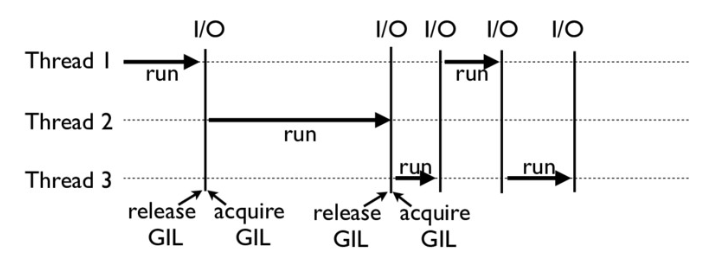

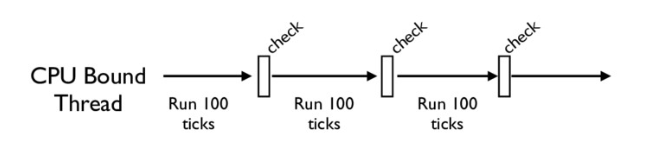

**GIL ≠ 线程安全**

有 GIL 并不代表python代码线程安全。

示例：

    n += 1

对应 4 条 bytecode，中间都可能被打断 → 产生 race condition。

因此仍需使用 Lock()：

    with lock:
      n += 1

In [15]:
import threading
import dis

n = 0

def foo():
  global n
  n += 1

#加锁，确保线程安全
lock = threading.Lock()
def foo2():
  global n
  with lock:
    n += 1

threads = []

for i in range(100):
  t = threading.Thread(target=foo)
  threads.append(t)

for t in threads:
  t.start()

for t in threads:
  t.join()
print(n)
print('-------------')
dis.dis(foo2)

100
-------------
 11           0 RESUME                   0

 13           2 LOAD_GLOBAL              0 (lock)
             12 BEFORE_WITH
             14 POP_TOP

 14          16 LOAD_GLOBAL              2 (n)
             26 LOAD_CONST               1 (1)
             28 BINARY_OP               13 (+=)
             32 STORE_GLOBAL             1 (n)

 13          34 LOAD_CONST               0 (None)
             36 LOAD_CONST               0 (None)
             38 LOAD_CONST               0 (None)
             40 CALL                     2
             48 POP_TOP
             50 RETURN_CONST             0 (None)
        >>   52 PUSH_EXC_INFO
             54 WITH_EXCEPT_START
             56 POP_JUMP_IF_TRUE         1 (to 60)
             58 RERAISE                  2
        >>   60 POP_TOP
             62 POP_EXCEPT
             64 POP_TOP
             66 POP_TOP
             68 RETURN_CONST             0 (None)
        >>   70 COPY                     3
             72 POP_EXCEPT
 

**为什么 CPU-bound 多线程更慢？**

原因：

线程切换需要成本

每次切换都要获取/释放 GIL

多核 CPU 上线程竞争更激烈

CPU-bound 任务无法真正并行

因此：CPU-bound → 多线程更慢。

**如何绕过 GIL？**

① 使用非 CPython 解释器

如 JPython（Java 实现），没有 GIL。

② 把性能关键代码放到 C/C++ 中实现

例如 NumPy 的矩阵运算在 C 层执行，不受 GIL 限制。

**GIL 的本质定位**

GIL 是 CPython 实现层面的折中方案

方便解释器开发，而不是为了应用层程序员

多线程 I/O-bound 场景仍然有效（遇到 I/O 会自动释放 GIL）